# Assignment 11: Image Classification Using Random Forest
# Student Name: Mohammad Tamim Hamkar


## Step 1: Import Libraries

In this step, I import the libraries needed for image processing, model training, evaluation, and visualization.

In [1]:
# Import libraries for file and image processing
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Extract the Image Dataset

In this step, I extract the image dataset and check the available image categories.

In [2]:
# Set the path for the ZIP file and extraction folder
zip_path = "/content/images.zip"
extract_path = "/content/images"

# Extract all images from the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Display the folders in the extracted dataset
print("Dataset extracted successfully.")
print("Folders:", os.listdir(extract_path))

Dataset extracted successfully.
Folders: ['images']


## Step 3: Check Image Categories

In this step, I check the image categories and count how many images are available in each class.

In [3]:
# Set the path to the actual image dataset
dataset_path = "/content/images/images"

# Get the image categories
class_names = sorted(os.listdir(dataset_path))

print("Image Categories:")
print(class_names)

# Count the number of images in each category
print("\nNumber of Images in Each Category:")

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        image_count = len(os.listdir(class_path))
        print(f"{class_name}: {image_count} images")

Image Categories:
['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']

Number of Images in Each Category:
dalmatian: 67 images
dollar_bill: 51 images
pizza: 52 images
soccer_ball: 54 images
sunflower: 85 images


## Step 4: Display Sample Images

In this step, I display one sample image from each category to better understand the dataset.

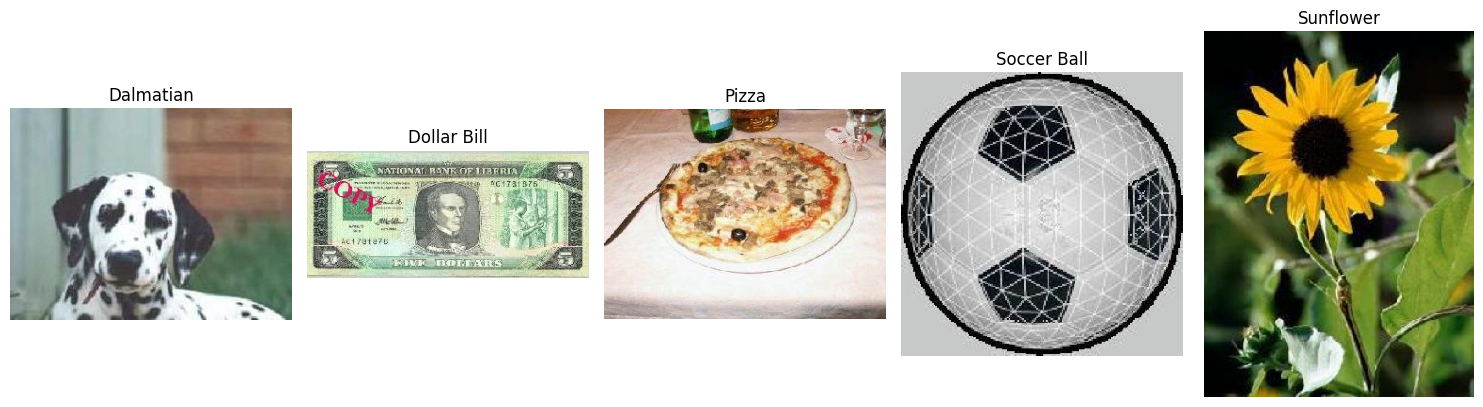

In [4]:
# Create a figure to display one image from each category
plt.figure(figsize=(15, 4))

# Loop through each image category
for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    # Select the first image from the category
    image_file = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_file)

    # Open and display the image
    image = Image.open(image_path)

    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("_", " ").title())
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Resize and Normalize the Images

Here, I resize all images to the same size and normalize the pixel values to prepare them for training.

In [5]:
# Set a uniform image size
image_size = (64, 64)

# Create lists to store image data and labels
X = []
y = []

# Loop through each image category
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    for image_file in os.listdir(class_path):
        image_path = os.path.join(class_path, image_file)

        try:
            # Open the image and convert it to RGB
            image = Image.open(image_path).convert("RGB")

            # Resize the image to 64 x 64 pixels
            image = image.resize(image_size)

            # Convert the image to a NumPy array and normalize pixels to 0-1
            image_array = np.array(image) / 255.0

            # Flatten the image for Random Forest
            X.append(image_array.flatten())
            y.append(class_name)

        except Exception:
            print(f"Could not process: {image_file}")

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print("Image preprocessing completed successfully.")
print("Feature shape:", X.shape)
print("Label shape:", y.shape)
print("Pixel value range:", X.min(), "to", X.max())

Image preprocessing completed successfully.
Feature shape: (309, 12288)
Label shape: (309,)
Pixel value range: 0.0 to 1.0


## Step 6: Split the Dataset

I split the images into training and testing sets so I can train the model and check how well it performs.

In [6]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of each dataset
print("Training images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training images: 247
Testing images: 62
Training feature shape: (247, 12288)
Testing feature shape: (62, 12288)


## Step 7: Tune the Random Forest Model

Here, I use GridSearchCV to find the best settings for the Random Forest model.

In [7]:
# Create the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Define the parameters to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# Train and test different parameter combinations
grid_search.fit(X_train, y_train)

# Get the best model
best_rf_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.7204427465961407


## Step 8: Evaluate the Random Forest Model

Here, I test the best Random Forest model and check how well it classifies the images.

In [8]:
# Make predictions on the test set
y_pred = best_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

# Display the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7741935483870968
Precision: 0.8337191953490765
Recall: 0.7741935483870968
F1 Score: 0.7551995351162885

Classification Report:
              precision    recall  f1-score   support

   dalmatian       0.63      0.86      0.73        14
 dollar_bill       0.67      1.00      0.80        10
       pizza       0.82      0.90      0.86        10
 soccer_ball       1.00      0.27      0.43        11
   sunflower       1.00      0.82      0.90        17

    accuracy                           0.77        62
   macro avg       0.82      0.77      0.74        62
weighted avg       0.83      0.77      0.76        62



## Step 9: Confusion Matrix

Here, I use a confusion matrix to see which image categories the model predicted correctly and where it made mistakes.

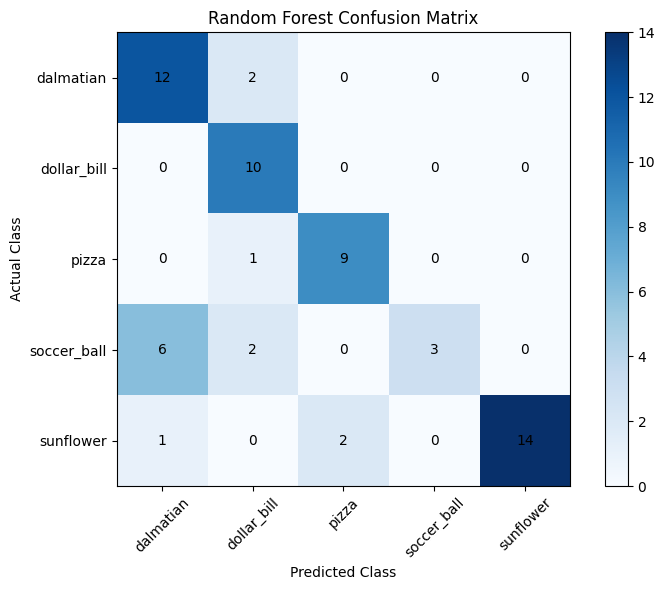

In [9]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_names)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.colorbar()

# Add class labels
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

# Add the values inside the matrix
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## Step 10: Feature Importance

Here, I look at which image features were most important to the Random Forest model.

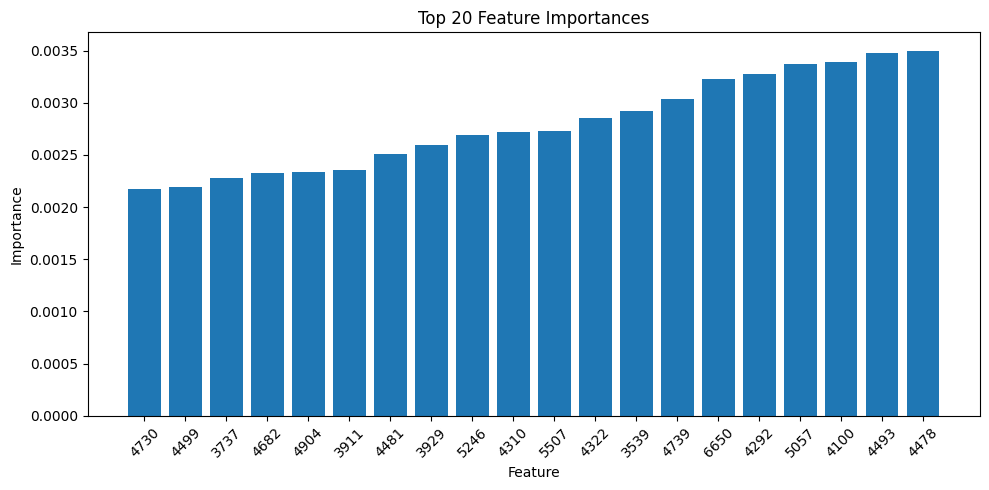

In [10]:
# Get feature importance values from the best model
feature_importances = best_rf_model.feature_importances_

# Select the 20 most important features
top_features = np.argsort(feature_importances)[-20:]

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(20), feature_importances[top_features])

plt.title("Top 20 Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(range(20), top_features, rotation=45)

plt.tight_layout()
plt.show()

## Step 11: Predict a New Image

Here, I create a function that prepares a new image and predicts its category using the trained Random Forest model.

In [11]:
# Create a function to predict a new image
def predict_new_image(image_path):
    # Open, resize, and normalize the image
    image = Image.open(image_path).convert("RGB")
    image = image.resize(image_size)
    image_array = np.array(image) / 255.0

    # Flatten the image for Random Forest
    image_array = image_array.flatten().reshape(1, -1)

    # Predict the image category
    prediction = best_rf_model.predict(image_array)[0]

    print("Predicted Class:", prediction)

    # Display the image
    plt.imshow(image)
    plt.title(f"Prediction: {prediction}")
    plt.axis("off")
    plt.show()

## Step 12: Test the Prediction

I test the function with an image and check the class predicted by the model.

Predicted Class: dollar_bill


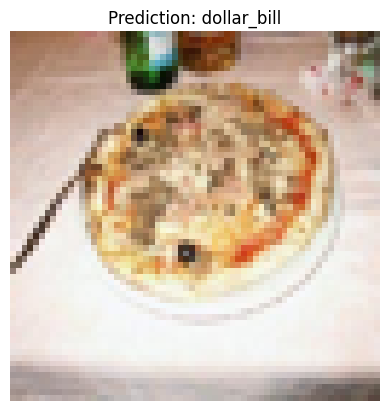

In [12]:
# Select an image to test the prediction function
test_image_path = os.path.join(
    dataset_path,
    "pizza",
    os.listdir(os.path.join(dataset_path, "pizza"))[0]
)

# Predict the class of the image
predict_new_image(test_image_path)

## Step 13: Model Interpretation and Deployment

The Random Forest model achieved about 77.42% accuracy. It performed well on several image categories, but it had more difficulty with some images, especially soccer balls.

In a real application, this model could be used to automatically classify new images into the five categories. The model could also be improved in the future by using more training images and a larger dataset.